<a href="https://colab.research.google.com/github/Lea17-hub/camera-optics-lab/blob/main/03_optical_aberrations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 03 — Optical Aberrations

## Question

How do different optical aberrations modify the PSF and affect image formation?

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import fftconvolve
from PIL import Image

N = 512
BASE_RADIUS = 0.35

In [2]:
def make_spherical_psf(radius=BASE_RADIUS, spherical=0.0, N=N):
    x = np.linspace(-1, 1, N)
    y = np.linspace(-1, 1, N)
    X, Y = np.meshgrid(x, y)

    R = np.sqrt(X**2 + Y**2)

    aperture = (R <= radius).astype(float)

    phase = np.exp(1j * spherical * R**4)

    pupil = aperture * phase

    field = np.fft.fftshift(np.fft.fft2(pupil))
    intensity = np.abs(field)**2

    psf = intensity / intensity.max()

    return psf

In [3]:
img = Image.open("1000052418.jpg").convert("L")
img = np.array(img) / 255.0

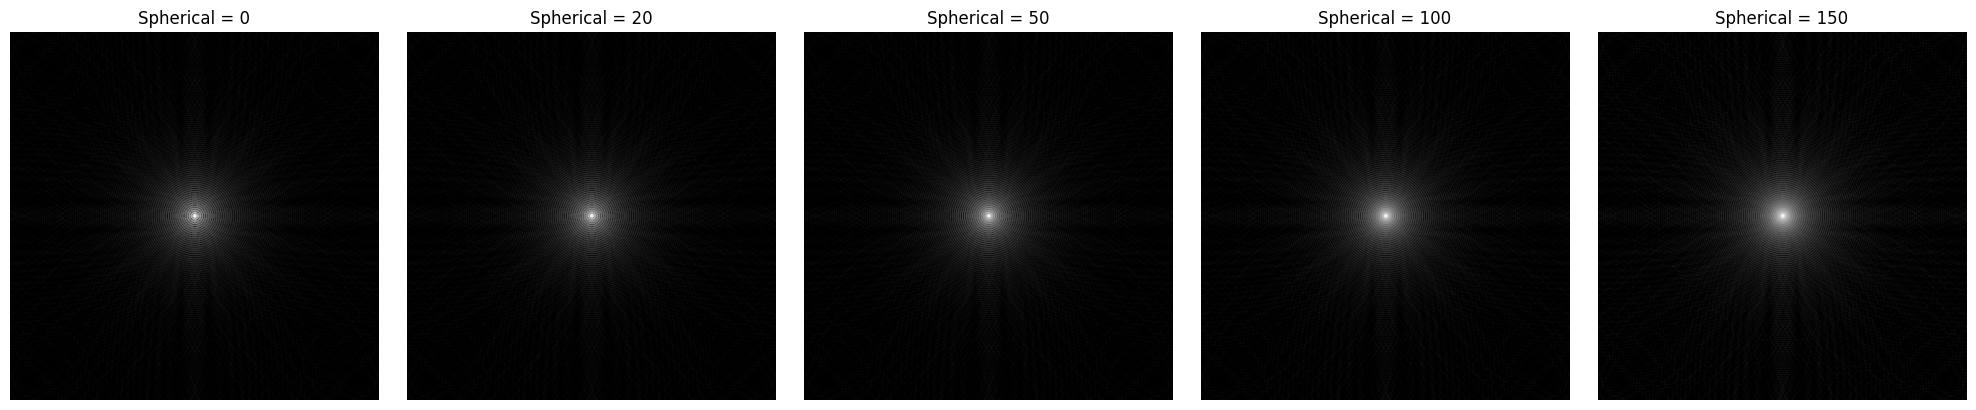

In [4]:
spherical_values = [0, 20, 50, 100, 150]

plt.figure(figsize=(20, 4))

for i, s in enumerate(spherical_values):
    psf_s = make_spherical_psf(
        radius=BASE_RADIUS,
        spherical=s
    )

    plt.subplot(1, len(spherical_values), i + 1)
    plt.imshow(np.log10(psf_s + 1e-6), cmap="gray")
    plt.title(f"Spherical = {s}")
    plt.axis("off")

plt.tight_layout()
plt.savefig("spherical_psf_sweep.png", dpi=300, bbox_inches="tight")
plt.show()

In [6]:
def make_defocused_psf(radius=BASE_RADIUS, defocus=0.0, N=N):
    x = np.linspace(-1, 1, N)
    y = np.linspace(-1, 1, N)
    X, Y = np.meshgrid(x, y)

    R = np.sqrt(X**2 + Y**2)

    aperture = (R <= radius).astype(float)

    phase = np.exp(1j * defocus * R**2)

    pupil = aperture * phase

    field = np.fft.fftshift(np.fft.fft2(pupil))
    intensity = np.abs(field)**2

    psf = intensity / intensity.max()

    return psf

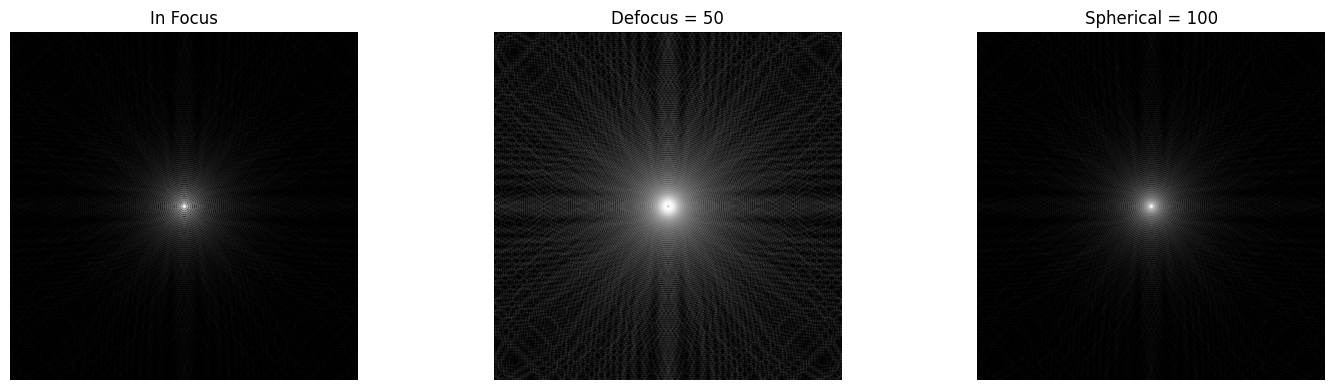

In [13]:
psf_focus = make_spherical_psf(
    radius=BASE_RADIUS,
    spherical=0
)

psf_defocus = make_defocused_psf(
    radius=BASE_RADIUS,
    defocus=50
)

psf_spherical = make_spherical_psf(
    radius=BASE_RADIUS,
    spherical=100
)

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.imshow(np.log10(psf_focus + 1e-6), cmap="gray")
plt.title("In Focus")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(np.log10(psf_defocus + 1e-6), cmap="gray")
plt.title("Defocus = 50")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(np.log10(psf_spherical + 1e-6), cmap="gray")
plt.title("Spherical = 100")
plt.axis("off")

plt.tight_layout()
plt.savefig("psf_comparison_focus_defocus_spherical.png", dpi=300, bbox_inches="tight")
plt.show()

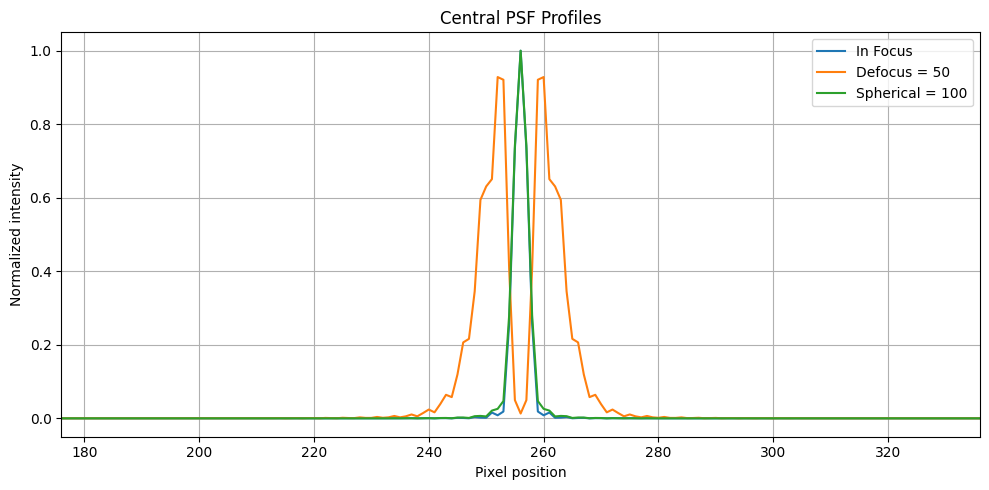

In [8]:
center = N // 2

profile_focus = psf_focus[center, :]
profile_defocus = psf_defocus[center, :]
profile_spherical = psf_spherical[center, :]

plt.figure(figsize=(10, 5))

plt.plot(profile_focus, label="In Focus")
plt.plot(profile_defocus, label="Defocus = 50")
plt.plot(profile_spherical, label="Spherical = 100")

plt.xlim(center - 80, center + 80)

plt.xlabel("Pixel position")
plt.ylabel("Normalized intensity")
plt.title("Central PSF Profiles")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

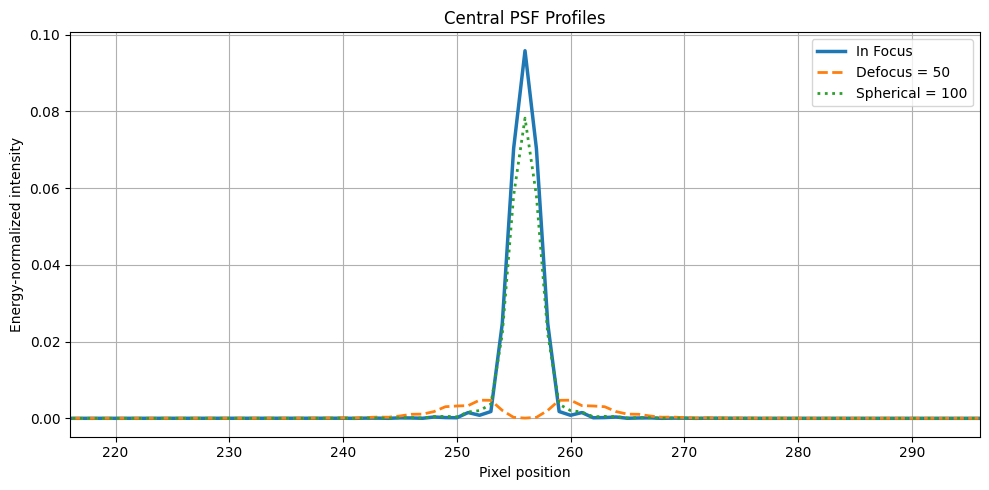

In [11]:
# Normalize by total energy instead of peak intensity
psf_focus_energy = psf_focus / psf_focus.sum()
psf_defocus_energy = psf_defocus / psf_defocus.sum()
psf_spherical_energy = psf_spherical / psf_spherical.sum()

center = N // 2

profile_focus = psf_focus_energy[center, :]
profile_defocus = psf_defocus_energy[center, :]
profile_spherical = psf_spherical_energy[center, :]

plt.figure(figsize=(10, 5))

plt.plot(
    profile_focus,
    label="In Focus",
    linewidth=2.5,
    linestyle="-"
)

plt.plot(
    profile_defocus,
    label="Defocus = 50",
    linewidth=2,
    linestyle="--"
)

plt.plot(
    profile_spherical,
    label="Spherical = 100",
    linewidth=2,
    linestyle=":"
)

plt.xlim(center - 40, center + 40)

plt.xlabel("Pixel position")
plt.ylabel("Energy-normalized intensity")
plt.title("Central PSF Profiles")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("central_psf_profiles_linear.png", dpi=300, bbox_inches="tight")
plt.show()

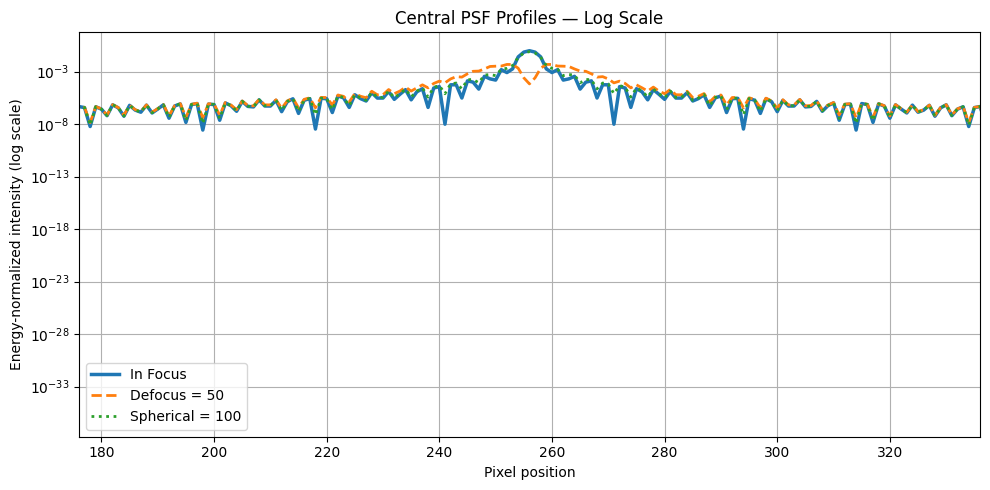

In [12]:
plt.figure(figsize=(10, 5))

plt.semilogy(profile_focus, label="In Focus", linewidth=2.5)
plt.semilogy(profile_defocus, label="Defocus = 50", linewidth=2, linestyle="--")
plt.semilogy(profile_spherical, label="Spherical = 100", linewidth=2, linestyle=":")

plt.xlim(center - 80, center + 80)

plt.xlabel("Pixel position")
plt.ylabel("Energy-normalized intensity (log scale)")
plt.title("Central PSF Profiles — Log Scale")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("central_psf_profiles_log.png", dpi=300, bbox_inches="tight")
plt.show()

In [14]:
# Make sure blur_with_psf is defined in this notebook
def blur_with_psf(img, psf, crop=81):
    center = psf.shape[0] // 2
    half = crop // 2

    kernel = psf[
        center-half:center+half+1,
        center-half:center+half+1
    ]

    kernel = kernel / kernel.sum()

    return fftconvolve(img, kernel, mode="same")

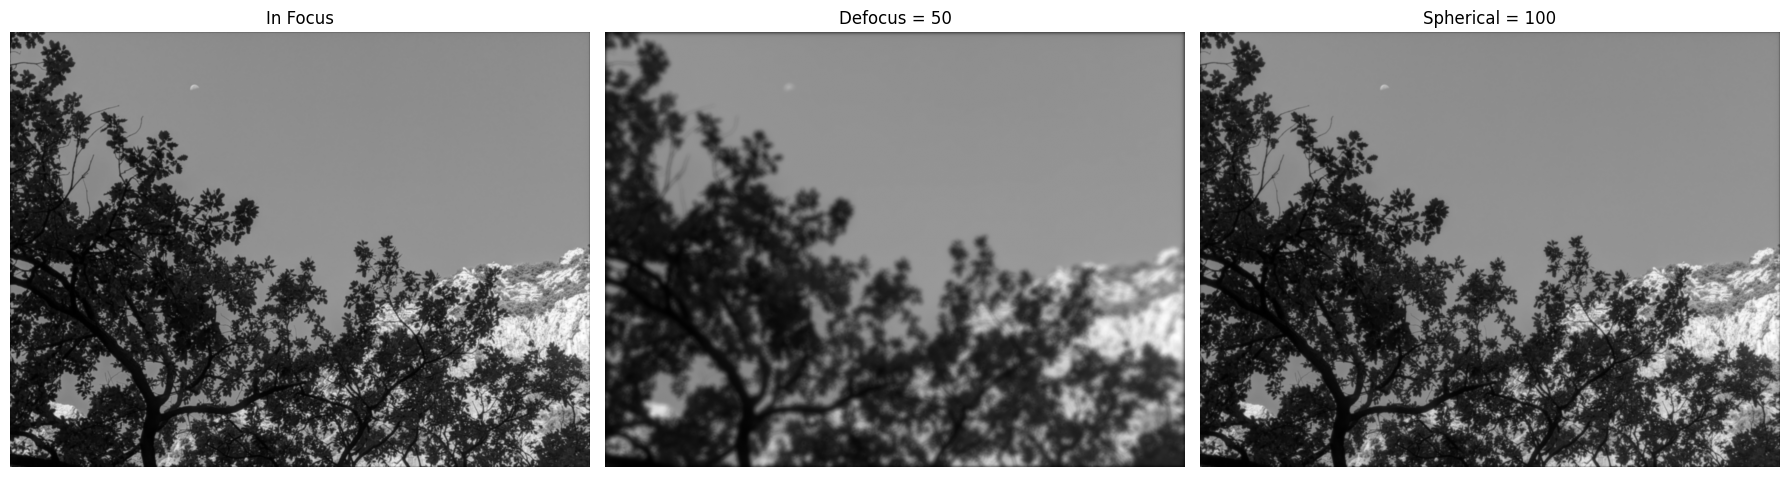

In [15]:
blur_focus = blur_with_psf(img, psf_focus)
blur_defocus = blur_with_psf(img, psf_defocus)
blur_spherical = blur_with_psf(img, psf_spherical)

plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(blur_focus, cmap="gray")
plt.title("In Focus")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(blur_defocus, cmap="gray")
plt.title("Defocus = 50")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(blur_spherical, cmap="gray")
plt.title("Spherical = 100")
plt.axis("off")

plt.tight_layout()

plt.savefig(
    "image_comparison_focus_defocus_spherical.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

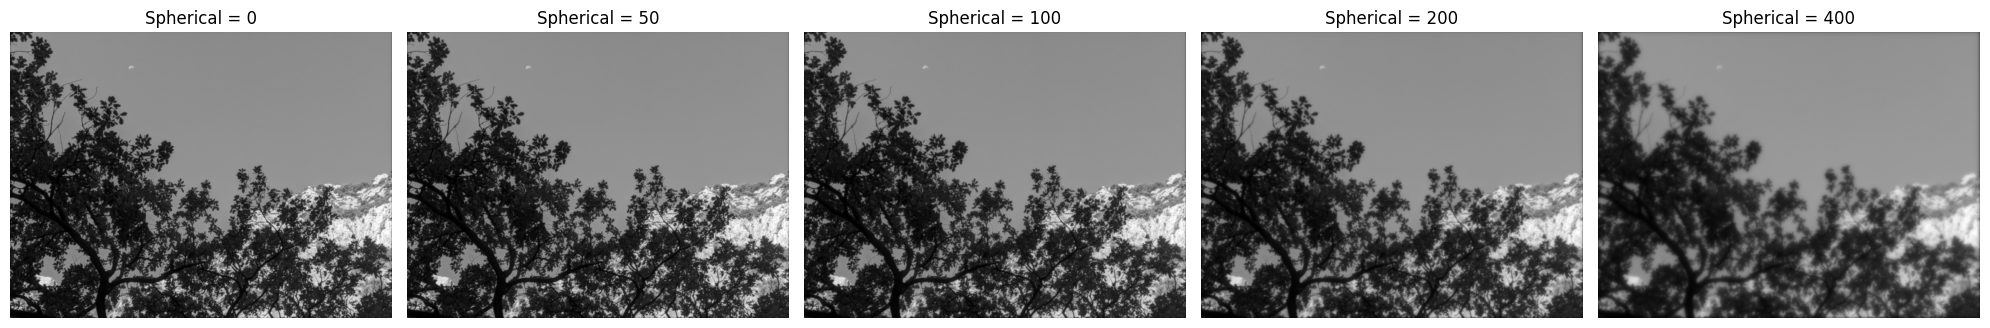

In [16]:
spherical_values = [0, 50, 100, 200, 400]

plt.figure(figsize=(20, 4))

for i, s in enumerate(spherical_values):
    psf_s = make_spherical_psf(
        radius=BASE_RADIUS,
        spherical=s
    )

    blur_s = blur_with_psf(img, psf_s)

    plt.subplot(1, len(spherical_values), i + 1)
    plt.imshow(blur_s, cmap="gray")
    plt.title(f"Spherical = {s}")
    plt.axis("off")

plt.tight_layout()

plt.savefig(
    "spherical_image_sweep.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

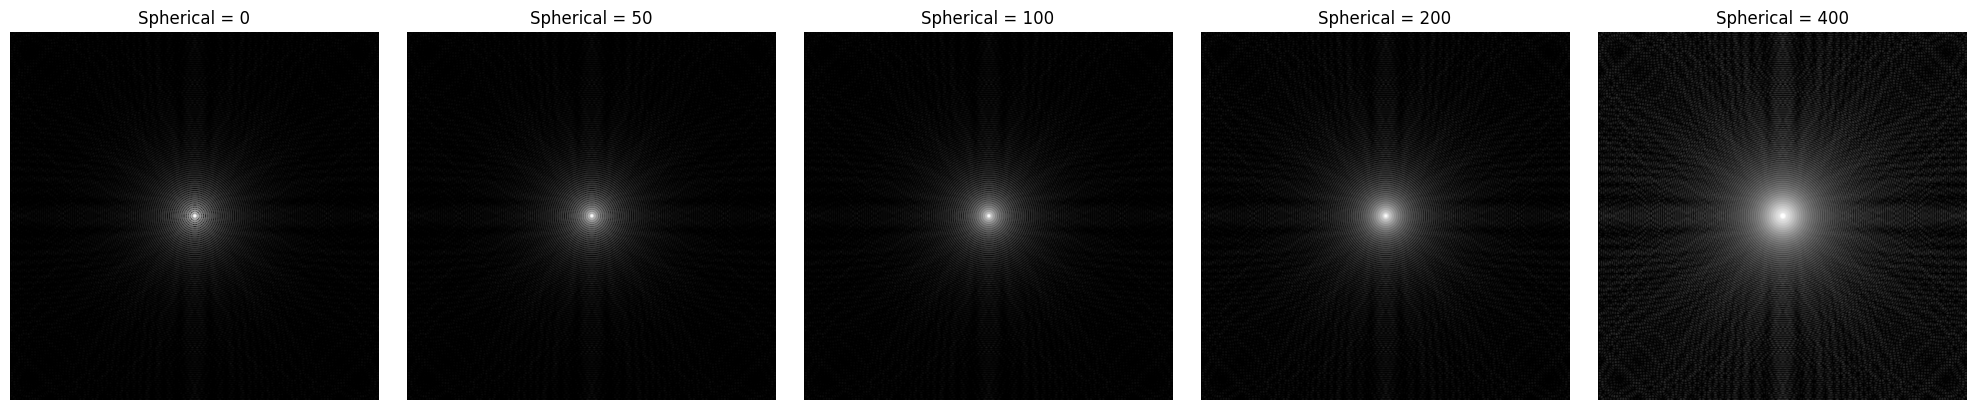

In [17]:
spherical_values = [0, 50, 100, 200, 400]

plt.figure(figsize=(20, 4))

for i, s in enumerate(spherical_values):
    psf_s = make_spherical_psf(
        radius=BASE_RADIUS,
        spherical=s
    )

    plt.subplot(1, len(spherical_values), i + 1)
    plt.imshow(np.log10(psf_s + 1e-6), cmap="gray")
    plt.title(f"Spherical = {s}")
    plt.axis("off")

plt.tight_layout()
plt.savefig("spherical_psf_sweep.png", dpi=300, bbox_inches="tight")
plt.show()

In [18]:
def make_coma_psf(radius=BASE_RADIUS, coma=0.0, N=N):
    x = np.linspace(-1, 1, N)
    y = np.linspace(-1, 1, N)
    X, Y = np.meshgrid(x, y)

    R = np.sqrt(X**2 + Y**2)

    aperture = (R <= radius).astype(float)

    phase = np.exp(1j * coma * X * R**2)

    pupil = aperture * phase

    field = np.fft.fftshift(np.fft.fft2(pupil))
    intensity = np.abs(field)**2

    psf = intensity / intensity.max()

    return psf

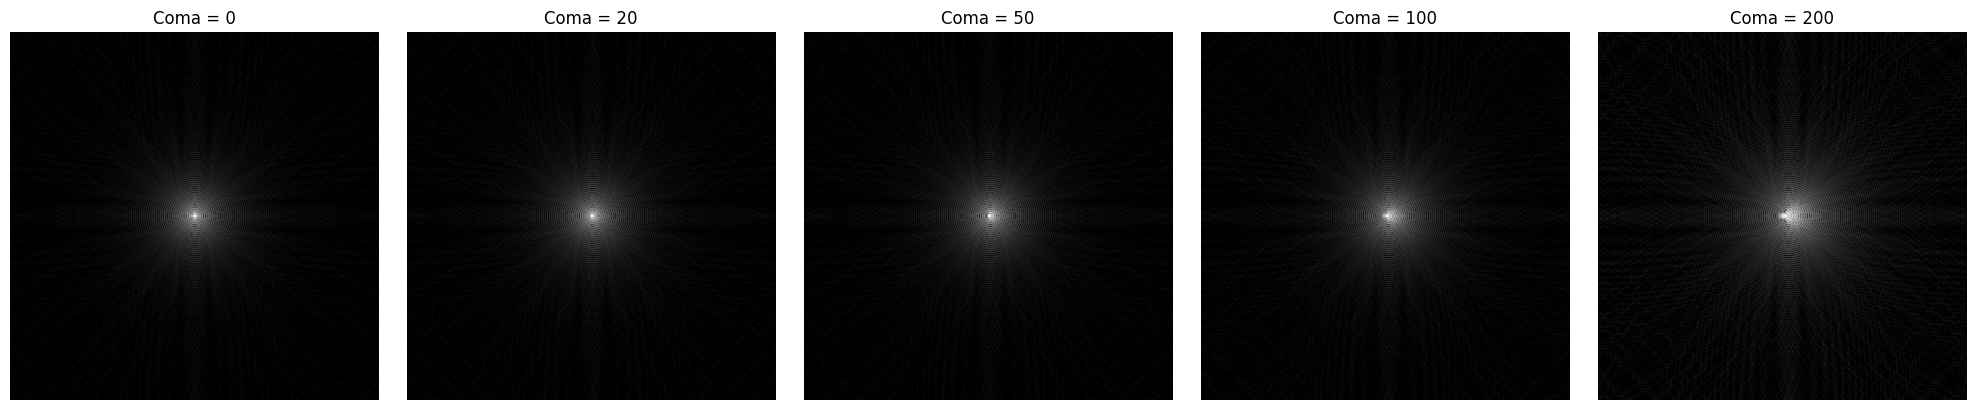

In [19]:
coma_values = [0, 20, 50, 100, 200]

plt.figure(figsize=(20, 4))

for i, c in enumerate(coma_values):
    psf_c = make_coma_psf(
        radius=BASE_RADIUS,
        coma=c
    )

    plt.subplot(1, len(coma_values), i + 1)
    plt.imshow(np.log10(psf_c + 1e-6), cmap="gray")
    plt.title(f"Coma = {c}")
    plt.axis("off")

plt.tight_layout()

plt.savefig(
    "coma_psf_sweep.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

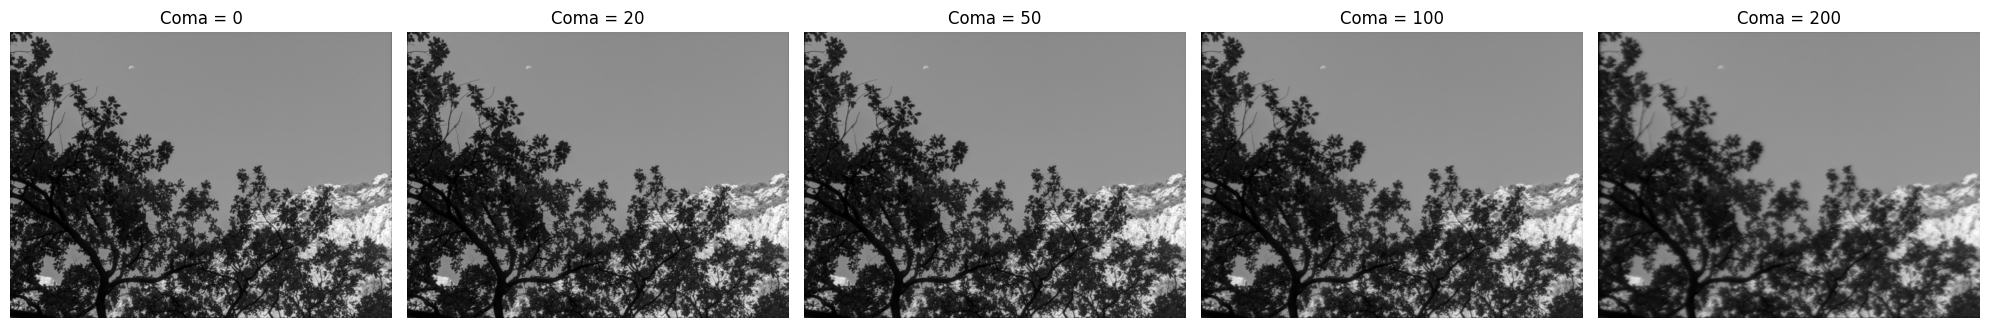

In [20]:
coma_values = [0, 20, 50, 100, 200]

plt.figure(figsize=(20, 4))

for i, c in enumerate(coma_values):
    psf_c = make_coma_psf(
        radius=BASE_RADIUS,
        coma=c
    )

    blur_c = blur_with_psf(img, psf_c)

    plt.subplot(1, len(coma_values), i + 1)
    plt.imshow(blur_c, cmap="gray")
    plt.title(f"Coma = {c}")
    plt.axis("off")

plt.tight_layout()

plt.savefig(
    "coma_image_sweep.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [21]:
def make_astigmatism_psf(radius=BASE_RADIUS, astigmatism=0.0, N=N):
    x = np.linspace(-1, 1, N)
    y = np.linspace(-1, 1, N)
    X, Y = np.meshgrid(x, y)

    R = np.sqrt(X**2 + Y**2)

    aperture = (R <= radius).astype(float)

    phase = np.exp(1j * astigmatism * (X**2 - Y**2))

    pupil = aperture * phase

    field = np.fft.fftshift(np.fft.fft2(pupil))
    intensity = np.abs(field)**2

    psf = intensity / intensity.max()

    return psf

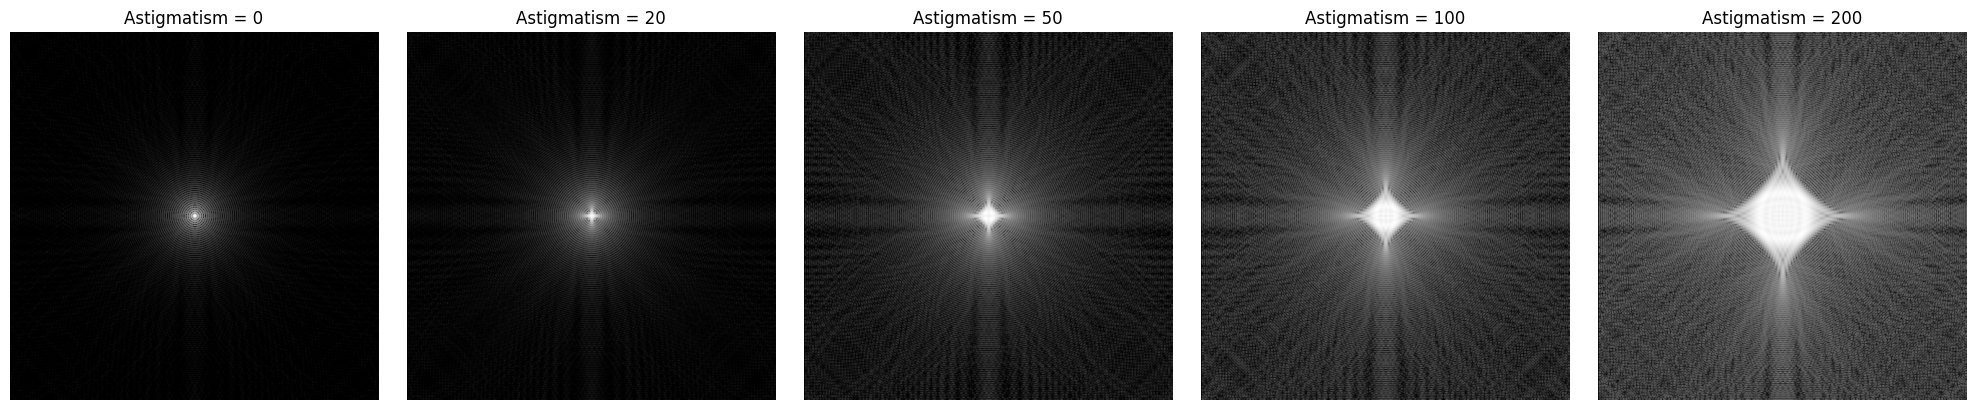

In [22]:
astig_values = [0, 20, 50, 100, 200]

plt.figure(figsize=(20, 4))

for i, a in enumerate(astig_values):
    psf_a = make_astigmatism_psf(
        radius=BASE_RADIUS,
        astigmatism=a
    )

    plt.subplot(1, len(astig_values), i + 1)
    plt.imshow(np.log10(psf_a + 1e-6), cmap="gray")
    plt.title(f"Astigmatism = {a}")
    plt.axis("off")

plt.tight_layout()

plt.savefig(
    "astigmatism_psf_sweep.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

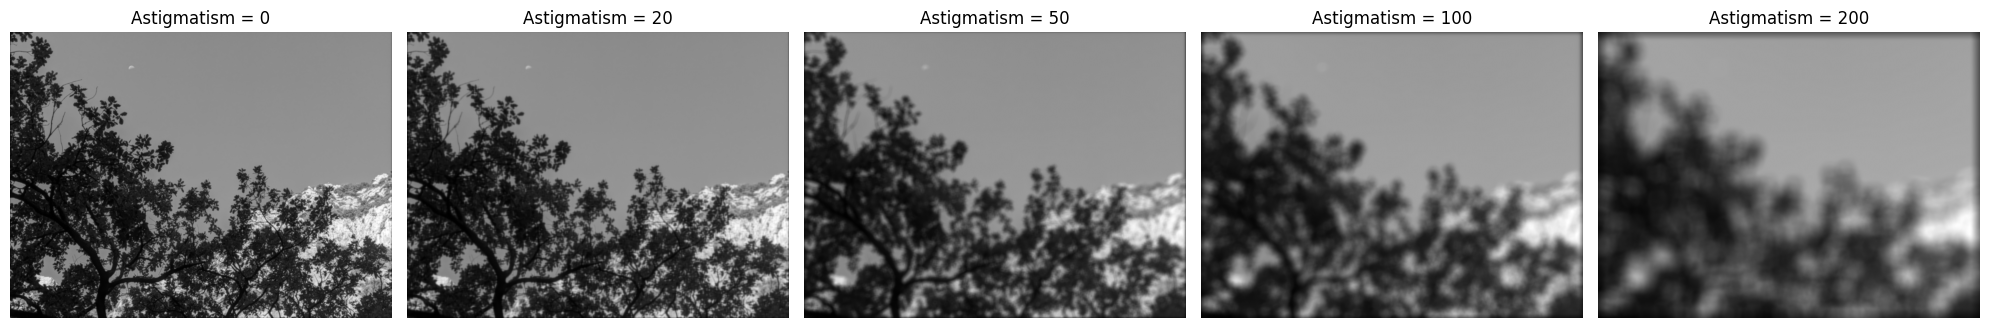

In [23]:
astig_values = [0, 20, 50, 100, 200]

plt.figure(figsize=(20, 4))

for i, a in enumerate(astig_values):
    psf_a = make_astigmatism_psf(
        radius=BASE_RADIUS,
        astigmatism=a
    )

    blur_a = blur_with_psf(img, psf_a)

    plt.subplot(1, len(astig_values), i + 1)
    plt.imshow(blur_a, cmap="gray")
    plt.title(f"Astigmatism = {a}")
    plt.axis("off")

plt.tight_layout()

plt.savefig(
    "astigmatism_image_sweep.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

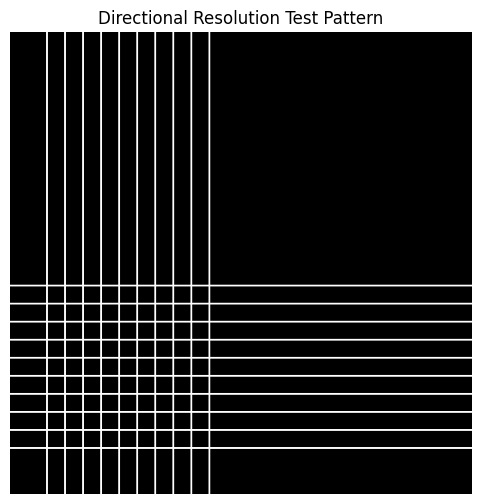

In [24]:
test_img = np.zeros((512, 512))

# vertical lines
for x in range(40, 240, 20):
    test_img[:, x:x+2] = 1.0

# horizontal lines
for y in range(280, 480, 20):
    test_img[y:y+2, :] = 1.0

plt.figure(figsize=(6, 6))
plt.imshow(test_img, cmap="gray")
plt.title("Directional Resolution Test Pattern")
plt.axis("off")

plt.savefig(
    "astigmatism_test_pattern.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

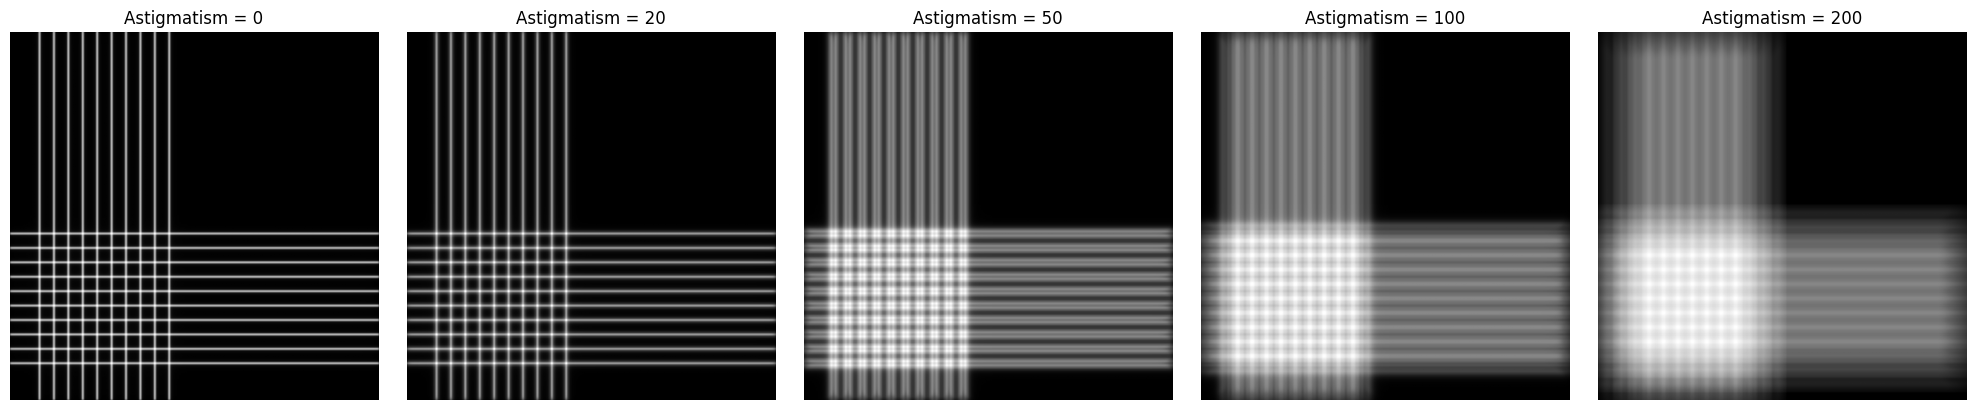

In [25]:
astig_values = [0, 20, 50, 100, 200]

plt.figure(figsize=(20, 4))

for i, a in enumerate(astig_values):
    psf_a = make_astigmatism_psf(
        radius=BASE_RADIUS,
        astigmatism=a
    )

    blur_a = blur_with_psf(test_img, psf_a)

    plt.subplot(1, len(astig_values), i + 1)
    plt.imshow(blur_a, cmap="gray")
    plt.title(f"Astigmatism = {a}")
    plt.axis("off")

plt.tight_layout()

plt.savefig(
    "astigmatism_directional_test.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [26]:
def make_astig_defocus_psf(
    radius=BASE_RADIUS,
    astigmatism=100,
    defocus=0.0,
    N=N
):
    x = np.linspace(-1, 1, N)
    y = np.linspace(-1, 1, N)
    X, Y = np.meshgrid(x, y)

    R = np.sqrt(X**2 + Y**2)

    aperture = (R <= radius).astype(float)

    phase = np.exp(
        1j * (
            defocus * R**2
            + astigmatism * (X**2 - Y**2)
        )
    )

    pupil = aperture * phase

    field = np.fft.fftshift(np.fft.fft2(pupil))
    intensity = np.abs(field)**2

    psf = intensity / intensity.max()

    return psf

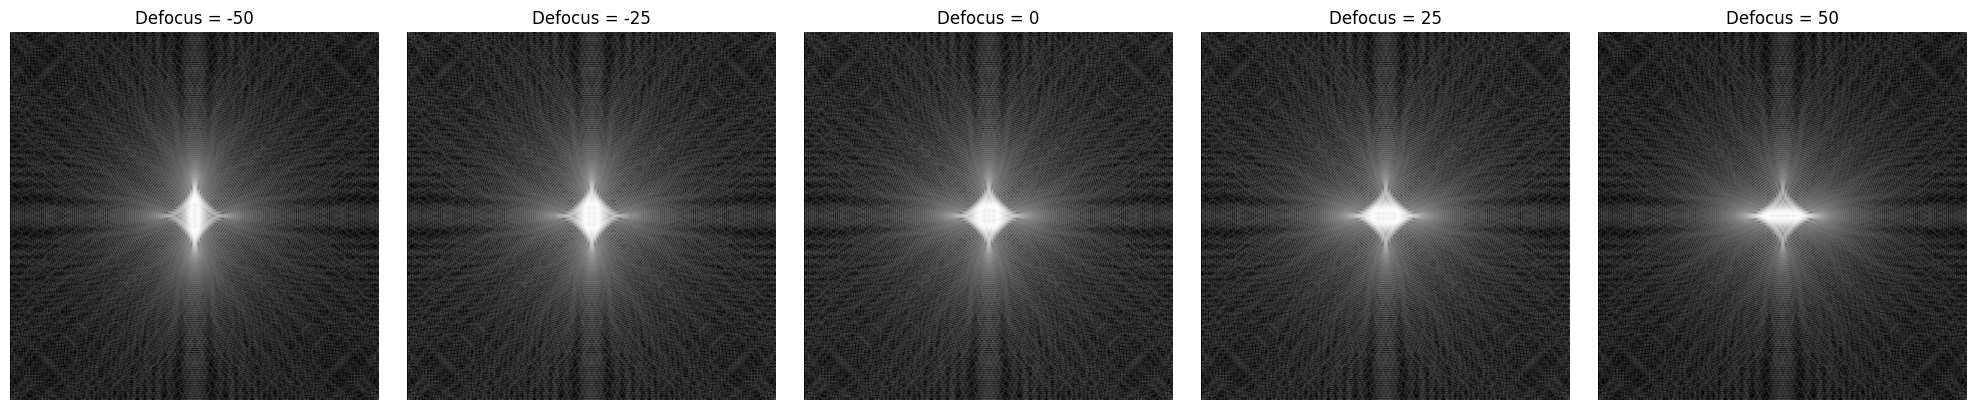

In [27]:
defocus_values = [-50, -25, 0, 25, 50]

plt.figure(figsize=(20, 4))

for i, d in enumerate(defocus_values):
    psf_ad = make_astig_defocus_psf(
        radius=BASE_RADIUS,
        astigmatism=100,
        defocus=d
    )

    plt.subplot(1, len(defocus_values), i + 1)
    plt.imshow(np.log10(psf_ad + 1e-6), cmap="gray")
    plt.title(f"Defocus = {d}")
    plt.axis("off")

plt.tight_layout()

plt.savefig(
    "astigmatism_focus_sweep_psf.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

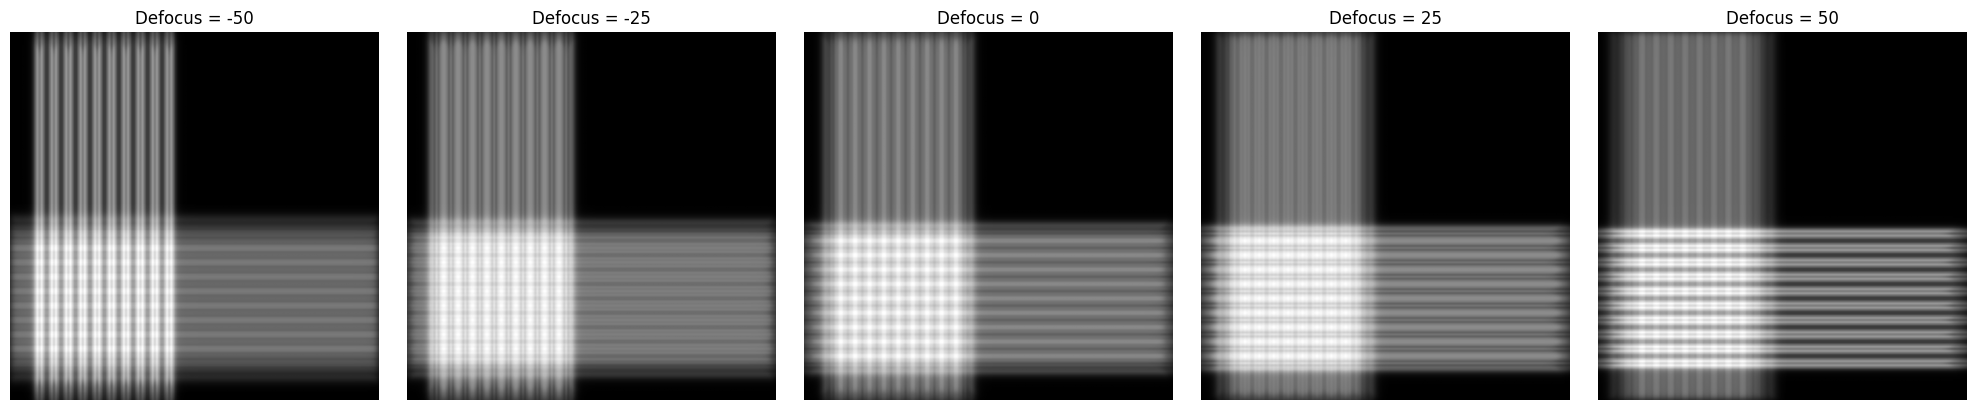

In [28]:
plt.figure(figsize=(20, 4))

for i, d in enumerate(defocus_values):
    psf_ad = make_astig_defocus_psf(
        radius=BASE_RADIUS,
        astigmatism=100,
        defocus=d
    )

    blur_ad = blur_with_psf(test_img, psf_ad)

    plt.subplot(1, len(defocus_values), i + 1)
    plt.imshow(blur_ad, cmap="gray")
    plt.title(f"Defocus = {d}")
    plt.axis("off")

plt.tight_layout()

plt.savefig(
    "astigmatism_focus_sweep_image.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()